In [ ]:
from google.colab import files
files.upload()  # Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c aptos2019-blindness-detection
!unzip -q aptos2019-blindness-detection.zip

Saving kaggle.json to kaggle.json
100% 9.51G/9.51G [01:06<00:00, 153MB/s] 



In [ ]:
!pip install -q timm

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, cohen_kappa_score
)
from sklearn.utils.class_weight import compute_class_weight

import timm
from tqdm import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("train.csv")

print("Class distribution:")
print(df["diagnosis"].value_counts().sort_index())
print(f"\nTotal samples: {len(df)}")

train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df["diagnosis"], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["diagnosis"], random_state=42
)

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

Total samples: 3662

Train: 2929 | Val: 366 | Test: 367


In [ ]:

def crop_black_borders(img):
    """Crop the black borders around the retina."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > 10
    coords = np.argwhere(mask)
    if coords.size == 0:
        return img
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img[y0:y1, x0:x1]


def apply_ben_graham(pil_img, sigmaX=10):
    """
    Ben Graham's preprocessing:
    1. Crop black borders
    2. Resize
    3. Subtract local average color (Gaussian blur)
    4. CLAHE on L channel
    """
    img = np.array(pil_img)

    img = crop_black_borders(img)

    img = cv2.resize(img, (300, 300))

    img = cv2.addWeighted(
        img, 4,
        cv2.GaussianBlur(img, (0, 0), sigmaX), -4,
        128
    )

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    lab = cv2.merge((cl, a, b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    return Image.fromarray(img)

In [ ]:

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Lambda(apply_ben_graham),
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.RandomAffine(
        degrees=0, translate=(0.05, 0.05),
        scale=(0.9, 1.1), shear=10
    ),
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3,
        saturation=0.2, hue=0.05
    ),
    transforms.RandomGrayscale(p=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15))
])

val_transform = transforms.Compose([
    transforms.Lambda(apply_ben_graham),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:

class APTOSDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]["id_code"]
        label = self.df.iloc[idx]["diagnosis"]

        path = f"train_images/{img_name}.png"
        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


BATCH_SIZE = 16
NUM_WORKERS = 2

train_loader = DataLoader(
    APTOSDataset(train_df, train_transform),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)

val_loader = DataLoader(
    APTOSDataset(val_df, val_transform),
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS, pin_memory=True
)

test_loader = DataLoader(
    APTOSDataset(test_df, val_transform),
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f"Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Batches — Train: 184 | Val: 23 | Test: 23


In [ ]:

class SwinDRModel(nn.Module):
    def __init__(self, num_classes=5, drop_rate=0.4, drop_path_rate=0.3):
        super().__init__()

        # KEY FIX: pretrained=True — uses ImageNet weights
        self.backbone = timm.create_model(
            "swin_base_patch4_window7_224",
            pretrained=True,
            num_classes=0,  # Remove default head
            drop_rate=drop_rate,
            drop_path_rate=drop_path_rate  # Stochastic depth
        )

        in_features = self.backbone.num_features  # 1024 for swin_base

        self.head = nn.Sequential(
            nn.LayerNorm(in_features),
            nn.Dropout(drop_rate),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(drop_rate / 2),
            nn.Linear(512, num_classes)
        )

        self._init_head()

    def _init_head(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)


model = SwinDRModel(
    num_classes=5,
    drop_rate=0.4,
    drop_path_rate=0.3
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params / 1e6:.1f}M")
print(f"Trainable params: {trainable_params / 1e6:.1f}M")

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Total params: 87.3M
Trainable params: 87.3M


In [ ]:

def mixup_data(x, y, alpha=0.2):
    """Apply Mixup augmentation to a batch."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Compute Mixup loss."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [ ]:

class_weights = compute_class_weight(
    "balanced",
    classes=np.unique(train_df["diagnosis"]),
    y=train_df["diagnosis"]
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class weights: {class_weights}")

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

Class weights: tensor([0.4057, 1.9791, 0.7332, 3.8039, 2.4822], device='cuda:0')


In [ ]:

def freeze_backbone(model):
    """Freeze backbone, keep head trainable."""
    for param in model.backbone.parameters():
        param.requires_grad = False
    for param in model.head.parameters():
        param.requires_grad = True


def unfreeze_all(model):
    """Unfreeze all parameters."""
    for param in model.parameters():
        param.requires_grad = True


def get_param_groups(model, backbone_lr, head_lr, weight_decay):
    """Differential learning rates: lower for backbone, higher for head."""
    backbone_params = []
    head_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if 'head' in name:
            head_params.append(param)
        else:
            backbone_params.append(param)

    return [
        {'params': backbone_params, 'lr': backbone_lr, 'weight_decay': weight_decay},
        {'params': head_params, 'lr': head_lr, 'weight_decay': weight_decay * 0.1}
    ]

In [ ]:

def train_model(model, train_loader, val_loader, total_epochs=25,
                warmup_epochs=3, patience=7, use_mixup=True, mixup_alpha=0.2):

    save_path = "/content/drive/MyDrive/swin_best_generalized.pth"

  
    freeze_backbone(model)

    head_params = [p for p in model.parameters() if p.requires_grad]
    print(f"\n🔥 Warmup Stage — Trainable param groups: {len(head_params)}")

    warmup_optimizer = torch.optim.AdamW(head_params, lr=1e-3, weight_decay=0.01)

    for epoch in range(warmup_epochs):
        model.train()
        loop = tqdm(train_loader, desc=f"Warmup {epoch+1}/{warmup_epochs}")

        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            warmup_optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(head_params, max_norm=1.0)
            warmup_optimizer.step()

            loop.set_postfix(loss=f"{loss.item():.4f}")

    unfreeze_all(model)

    # Differential learning rates
    param_groups = get_param_groups(
        model,
        backbone_lr=2e-5,   # Lower LR for pretrained backbone
        head_lr=5e-4,       # Higher LR for head
        weight_decay=0.01   # KEY: L2 regularization
    )

    optimizer = torch.optim.AdamW(param_groups)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=5, T_mult=2, eta_min=1e-7
    )

    # Tracking
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0
    best_val_kappa = 0
    epochs_no_improve = 0

    print(f"\n🚀 Full Training — {total_epochs} epochs (patience={patience})\n")

    for epoch in range(total_epochs):

        model.train()
        running_loss, correct, total = 0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{total_epochs}")

        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            if use_mixup and np.random.random() > 0.3:
                mixed_images, y_a, y_b, lam = mixup_data(images, labels, mixup_alpha)
                outputs = model(mixed_images)
                loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)

                _, preds = torch.max(outputs, 1)
                correct += (lam * (preds == y_a).float().sum().item() +
                           (1 - lam) * (preds == y_b).float().sum().item())
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            running_loss += loss.item()
            total += labels.size(0)
            loop.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        model.eval()
        val_loss, correct, total = 0, 0, 0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)
        val_acc = correct / total
        val_kappa = cohen_kappa_score(all_labels, all_preds, weights="quadratic")

        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        gap = train_acc - val_acc
        current_lr = optimizer.param_groups[0]['lr']
        print(f"\n📊 Epoch {epoch+1}/{total_epochs} | LR: {current_lr:.2e}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | QWK: {val_kappa:.4f}")
        print(f"Gap (Train-Val): {gap:.4f}")
        print("-" * 55)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_kappa = val_kappa
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f"✅ Best model saved! Val Acc: {val_acc:.4f} | QWK: {val_kappa:.4f}")
        else:
            epochs_no_improve += 1
            print(f"⏳ No improvement for {epochs_no_improve}/{patience} epochs")

        if epochs_no_improve >= patience:
            print(f"\n🛑 Early stopping at epoch {epoch+1}")
            break

    print(f"\n🏆 Best Val Acc: {best_val_acc:.4f} | Best QWK: {best_val_kappa:.4f}")
    return train_losses, val_losses, train_accs, val_accs

In [ ]:
history = train_model(
    model, train_loader, val_loader,
    total_epochs=25,
    warmup_epochs=3,
    patience=7,
    use_mixup=True,
    mixup_alpha=0.2
)


🔥 Warmup Stage — Trainable param groups: 6


Warmup 3/3: 100%|██████████| 184/184 [08:09<00:00,  2.66s/it, loss=1.1580]



🚀 Full Training — 25 epochs (patience=7)



Epoch 1/25: 100%|██████████| 184/184 [08:38<00:00,  2.82s/it, acc=0.5564, loss=1.4532]



📊 Epoch 1/25 | LR: 1.81e-05
Train Loss: 1.5212 | Train Acc: 0.5564
Val   Loss: 1.4794 | Val   Acc: 0.6885 | QWK: 0.7139
Gap (Train-Val): -0.1321
-------------------------------------------------------
✅ Best model saved! Val Acc: 0.6885 | QWK: 0.7139


...


📊 Epoch 19/25 | LR: 1.81e-05
Train Loss: 1.2763 | Train Acc: 0.7477
Val   Loss: 1.3167 | Val   Acc: 0.7705 | QWK: 0.8656
Gap (Train-Val): -0.0228
-------------------------------------------------------
⏳ No improvement for 5/7 epochs


Epoch 20/25: 100%|██████████| 184/184 [09:44<00:00,  3.18s/it, acc=0.7564, loss=1.4666]



📊 Epoch 20/25 | LR: 1.71e-05
Train Loss: 1.2411 | Train Acc: 0.7564
Val   Loss: 1.4094 | Val   Acc: 0.8087 | QWK: 0.8679
Gap (Train-Val): -0.0523
-------------------------------------------------------
⏳ No improvement for 6/7 epochs


Epoch 21/25: 100%|██████████| 184/184 [09:47<00:00,  3.19s/it, acc=0.7445, loss=1.4246]



📊 Epoch 21/25 | LR: 1.59e-05
Train Loss: 1.2613 | Train Acc: 0.7445
Val   Loss: 1.3033 | Val   Acc: 0.7951 | QWK: 0.8699
Gap (Train-Val): -0.0506
-------------------------------------------------------
⏳ No improvement for 7/7 epochs

🛑 Early stopping at epoch 21

🏆 Best Val Acc: 0.8142 | Best QWK: 0.8854


Final Train-Val Gap: -0.0506
Max Train-Val Gap:   -0.0077


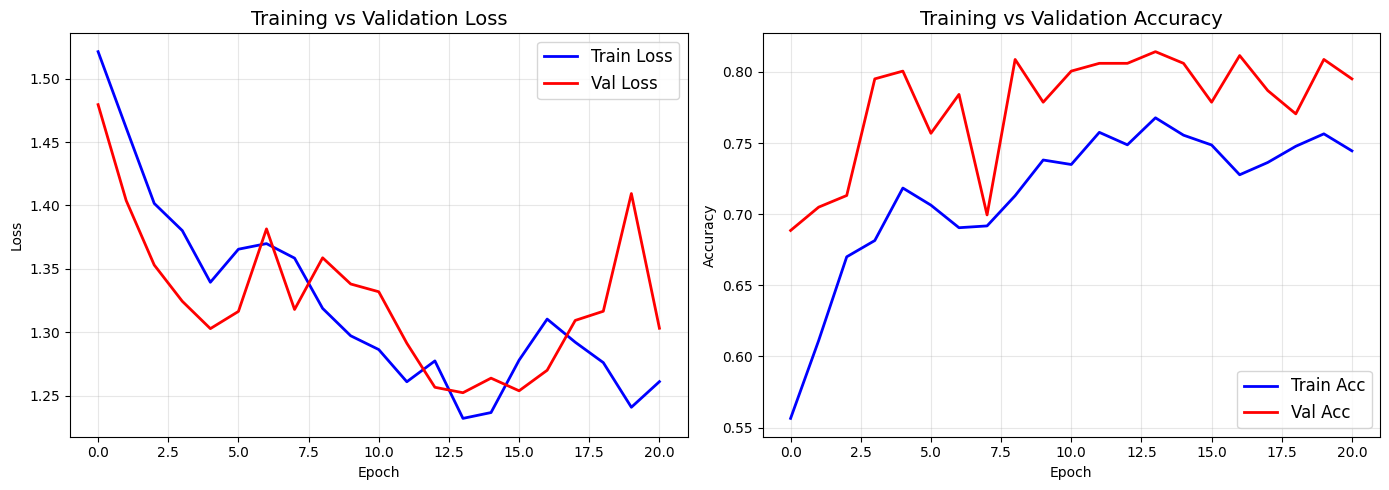

In [ ]:

def plot_history(history):
    train_losses, val_losses, train_accs, val_accs = history

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(train_losses, 'b-', label='Train Loss', linewidth=2)
    ax1.plot(val_losses, 'r-', label='Val Loss', linewidth=2)
    ax1.set_title('Training vs Validation Loss', fontsize=14)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.3)

    ax2.plot(train_accs, 'b-', label='Train Acc', linewidth=2)
    ax2.plot(val_accs, 'r-', label='Val Acc', linewidth=2)
    ax2.set_title('Training vs Validation Accuracy', fontsize=14)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend(fontsize=12)
    ax2.grid(True, alpha=0.3)

    gaps = [t - v for t, v in zip(train_accs, val_accs)]
    print(f"Final Train-Val Gap: {gaps[-1]:.4f}")
    print(f"Max Train-Val Gap:   {max(gaps):.4f}")

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/swin_training_curves.png', dpi=150)
    plt.show()

plot_history(history)

In [ ]:

def get_tta_transforms():
    """5 augmentations for TTA."""
    return [
        val_transform,  
        transforms.Compose([  
            transforms.Lambda(apply_ben_graham),
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
        transforms.Compose([  
            transforms.Lambda(apply_ben_graham),
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomVerticalFlip(p=1.0),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
        transforms.Compose([  
            transforms.Lambda(apply_ben_graham),
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomRotation((90, 90)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
        transforms.Compose([  
            transforms.Lambda(apply_ben_graham),
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.RandomVerticalFlip(p=1.0),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    ]


def evaluate_with_tta(model, test_df, tta_transforms):
    """Evaluate with Test-Time Augmentation."""
    model.eval()

    all_preds = []
    all_labels = []

    for idx in tqdm(range(len(test_df)), desc="TTA Evaluation"):
        img_name = test_df.iloc[idx]["id_code"]
        label = test_df.iloc[idx]["diagnosis"]

        path = f"train_images/{img_name}.png"
        image = Image.open(path).convert("RGB")

        logits_sum = None

        with torch.no_grad():
            for t in tta_transforms:
                aug_img = t(image).unsqueeze(0).to(device)
                logits = model(aug_img)

                if logits_sum is None:
                    logits_sum = logits
                else:
                    logits_sum += logits

        avg_logits = logits_sum / len(tta_transforms)
        pred = avg_logits.argmax(1).item()

        all_preds.append(pred)
        all_labels.append(label)

    return all_preds, all_labels

In [ ]:

=model.load_state_dict(
    torch.load("/content/drive/MyDrive/swin_best_generalized.pth", map_location=device)
)
model.eval()
print("✅ Best model loaded")

print("\n" + "=" * 50)
print("📊 STANDARD TEST EVALUATION")
print("=" * 50)

preds_std, labels_std = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds_std.extend(outputs.argmax(1).cpu().numpy())
        labels_std.extend(labels.numpy())

print(classification_report(labels_std, preds_std))
qwk_std = cohen_kappa_score(labels_std, preds_std, weights="quadratic")
print(f"QWK (standard): {qwk_std:.4f}")

print("\n" + "=" * 50)
print("📊 TTA TEST EVALUATION")
print("=" * 50)

tta_transforms = get_tta_transforms()
preds_tta, labels_tta = evaluate_with_tta(
    model, test_df.reset_index(drop=True), tta_transforms
)

print(classification_report(labels_tta, preds_tta))
qwk_tta = cohen_kappa_score(labels_tta, preds_tta, weights="quadratic")
print(f"QWK (with TTA): {qwk_tta:.4f}")

✅ Best model loaded

📊 STANDARD TEST EVALUATION
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       181
           1       0.56      0.54      0.55        37
           2       0.74      0.66      0.70       100
           3       0.38      0.53      0.44        19
           4       0.60      0.60      0.60        30

    accuracy                           0.80       367
   macro avg       0.65      0.66      0.65       367
weighted avg       0.80      0.80      0.80       367

QWK (standard): 0.8909

📊 TTA TEST EVALUATION


TTA Evaluation: 100%|██████████| 367/367 [04:32<00:00,  1.35it/s]

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       181
           1       0.55      0.46      0.50        37
           2       0.72      0.66      0.69       100
           3       0.38      0.53      0.44        19
           4       0.59      0.63      0.61        30

    accuracy                           0.79       367
   macro avg       0.64      0.65      0.64       367
weighted avg       0.79      0.79      0.79       367

QWK (with TTA): 0.8979


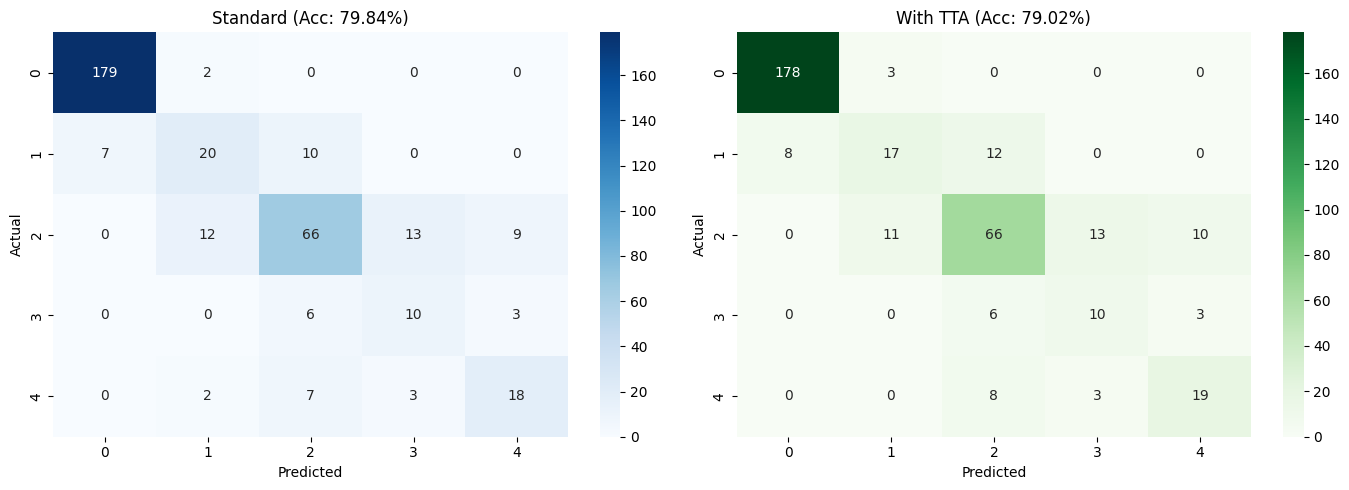

In [ ]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Standard
cm1 = confusion_matrix(labels_std, preds_std)
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues", ax=ax1)
ax1.set_title(f"Standard (Acc: {sum(np.array(preds_std)==np.array(labels_std))/len(labels_std):.2%})")
ax1.set_xlabel("Predicted")
ax1.set_ylabel("Actual")

cm2 = confusion_matrix(labels_tta, preds_tta)
sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens", ax=ax2)
ax2.set_title(f"With TTA (Acc: {sum(np.array(preds_tta)==np.array(labels_tta))/len(labels_tta):.2%})")
ax2.set_xlabel("Predicted")
ax2.set_ylabel("Actual")

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/swin_confusion_matrices.png', dpi=150)
plt.show()